# Graph Neural Networks (GNNs)
## Part II: Transformer
We are going to play with attention in the context for molecular property prediciton. It's recommended that you're familiar with the recent lectures on GNNs and with the previous lab on MPNN in molecular property prediction.

DEPENDENCIES

In [2]:
!git clone https://github.com/gmum/ml2024-25.git

import sys
import shutil
import os
sys.path.append('/content/ml2024-25')  # This ensures import lab.checker later
files_to_move = {
    "./ml2024-25/lab/checker.py": "./checker.py",
    "./ml2024-25/lab/utils.py": "./utils.py"
}

for source, destination in files_to_move.items():
    if os.path.exists(source):
        shutil.move(source, destination)

!pip install torch==2.4.0 torchvision==0.19.0 torchaudio==2.4.0 --index-url https://download.pytorch.org/whl/cu121
!pip install  dgl -f https://data.dgl.ai/wheels/torch-2.4/cu121/repo.html
!pip install dgllife
!pip install torch_geometric
!pip install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.4.0+cu121.html  # Optional dependencies
!pip install rdkit
!pip install torchmetrics

fatal: destination path 'ml2024-25' already exists and is not an empty directory.
Looking in indexes: https://download.pytorch.org/whl/cu121
Looking in links: https://data.dgl.ai/wheels/torch-2.4/cu121/repo.html
Looking in links: https://data.pyg.org/whl/torch-2.4.0+cu121.html


## Copied code
I'm going to copy most of the code for convenience.

In [3]:
import copy
from abc import ABC, abstractmethod
from pathlib import Path
from typing import Dict, Any, Tuple
from typing import Type

import dgl
import numpy as np
import torch
from dgl.data import Subset
from dgl.dataloading import GraphDataLoader
from dgllife.data import FreeSolv
from dgllife.utils import CanonicalAtomFeaturizer, SMILESToBigraph
from dgllife.utils import ScaffoldSplitter
from torch import nn
from torch_geometric.utils import to_dense_batch
from torchmetrics import Metric
from tqdm.autonotebook import tqdm

from checker import expected_gat_output, expected_dot_attention_output, sub_optimal_multihead_attention_output, \
    expected_multihead_attention_output
import utils

In [4]:
class LoggerBase(ABC):
    def __init__(self, logdir: str | Path):
        self.logdir = Path(logdir)
        self.logdir.mkdir(parents=True, exist_ok=True)

    @abstractmethod
    def log_metrics(self, metrics: Dict[str, Any], prefix: str):
        ...

    @abstractmethod
    def close(self):
        ...


class WandbLogger(LoggerBase):
    def __init__(
            self, logdir: str | Path, project_name: str, experiment_name: str, **kwargs: Dict[str, Any]
    ):
        super().__init__(logdir)
        import wandb
        self.project_name = project_name
        self.experiment_name = experiment_name
        self.kwargs = kwargs
        self.run = wandb.init(
            dir=self.logdir,
            project=self.project_name,
            name=self.experiment_name,
            **self.kwargs,
        )

    def log_metrics(self, metrics: Dict[str, Any], prefix: str):
        metrics = {f"{prefix}/{k}": v for k, v in metrics.items()}
        self.run.log(metrics)

    def close(self):
        self.run.finish()


class DummyLogger(LoggerBase):  # If you don't want to use any logger, you can use this one
    def log_metrics(self, metrics: Dict[str, Any], prefix: str):
        pass

    def close(self):
        pass

    def restart(self):
        pass


class MetricList:
    def __init__(self, metrics: Dict[str, Metric]):
        self.metrics = copy.deepcopy(metrics)

    def update(self, preds: torch.Tensor, targets: torch.Tensor) -> None:
        for name, metric in self.metrics.items():
            metric.update(preds.detach().cpu(), targets.cpu())

    def compute(self) -> Dict[str, float]:
        metrics = {}
        for name, metric_fn in self.metrics.items():
            metrics[name] = metric_fn.compute().item()
            metric_fn.reset()
        return metrics


class Trainer:
    def __init__(
            self,
            *,
            run_dir: str | Path,
            train_dataset: Subset,
            valid_dataset: Subset,
            train_metrics: Dict[str, Metric],
            valid_metrics: Dict[str, Metric],
            model: nn.Module,
            logger: LoggerBase,
            optimizer_kwargs: Dict[str, Any],
            optimizer_cls: Type[torch.optim.Optimizer] = torch.optim.Adam,
            n_epochs: int,
            train_batch_size: int = 32,
            valid_batch_size: int = 16,
            device: str = "cuda",
            valid_every_n_epochs: int = 1,
            loss_fn=nn.MSELoss()
    ):
        self.run_dir = Path(run_dir)
        self.train_loader = GraphDataLoader(
            dataset=train_dataset,
            batch_size=train_batch_size,
            shuffle=True,
        )
        self.valid_loader = GraphDataLoader(
            dataset=valid_dataset,
            batch_size=valid_batch_size,
            shuffle=True,
        )
        self.train_metrics = MetricList(train_metrics)
        self.valid_metrics = MetricList(valid_metrics)
        self.logger = logger
        self.model = model
        self.optimizer = optimizer_cls(model.parameters(), **optimizer_kwargs)
        self.n_epochs = n_epochs
        self.device = device
        self.valid_every_n_epochs = valid_every_n_epochs
        self.loss_fn = loss_fn
        self.model.to(device)

    @torch.no_grad()
    def validate(self, dataloader: GraphDataLoader, prefix: str) -> Dict[str, float]:
        previous_mode = self.model.training
        self.model.eval()
        losses = []
        for _, graphs, labels in dataloader:
            graphs = graphs.to(self.device)
            labels = labels.to(self.device)
            preds = self.model(graphs)
            loss = self.loss_fn(preds, labels)
            losses.append(loss.item())
            self.valid_metrics.update(preds, labels)
        self.model.train(mode=previous_mode)
        metrics = {"loss": np.mean(losses)} | self.valid_metrics.compute()
        self.logger.log_metrics(metrics=metrics, prefix=prefix)
        return metrics

    def train(self) -> Dict[str, float]:
        self.model.train()
        valid_metrics = {}
        for epoch in tqdm(range(self.n_epochs), total=self.n_epochs):
            for _, graphs, labels in self.train_loader:
                self.optimizer.zero_grad()
                graphs = graphs.to(self.device)
                labels = labels.to(self.device)
                preds = self.model(graphs)
                loss = self.loss_fn(preds, labels)
                loss.backward()
                self.optimizer.step()

                self.train_metrics.update(preds, labels)
                train_metrics = {"loss": loss.item()} | self.train_metrics.compute()
                self.logger.log_metrics(metrics=train_metrics, prefix="train")

                if epoch % self.valid_every_n_epochs == 0 or epoch == self.n_epochs - 1:
                    valid_metrics = self.validate(self.valid_loader, prefix="valid")

        return valid_metrics

    def test(self, dataset: Subset) -> Dict[str, float]:
        dataloader = GraphDataLoader(
            dataset=dataset,
            batch_size=16,
            shuffle=False,
        )
        return self.validate(dataloader, prefix="test")

    def close(self):  # close the logger, not really required for wandb
        self.logger.close()

In [5]:
def to_dense_embeddings(node_embeddings: torch.Tensor, graph: dgl.DGLGraph, fill_value: float = 0.0) -> Tuple[
    torch.Tensor, torch.Tensor]:
    """
    Converts sparse node embeddings to dense node embeddings with padding.
    Arguments:
        node_embeddings: node embeddings in a sparse format, i.e. [total_num_nodes, hidden_size]
        graph: a batch of graphs
        fill_value: a value to fill the padding with
    Returns:
        node_embeddings: node embeddings in a dense format, i.e. [batch_size, max_num_nodes, hidden_size]
        mask: a mask indicating which nodes are real and which are padding, i.e. [batch_size, max_num_nodes]
    """
    num_nodes = graph.batch_num_nodes()  # e.g. [2, 3, 3]
    indices = torch.arange(len(num_nodes), device=num_nodes.device)
    batch = torch.repeat_interleave(indices, num_nodes).long()  # e.g. [0, 0, 1, 1, 1, 2, 2, 2]
    return to_dense_batch(node_embeddings, batch,
                          fill_value=fill_value)  # that's the only reason we have torch_geometric in the requirements


def to_sparse_embeddings(node_embeddings: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
    """
    Converts dense node embeddings to sparse node embeddings.
    Arguments:
        node_embeddings: node embeddings in a dense format, i.e. [batch_size, max_num_nodes, hidden_size]
        mask: a mask indicating which nodes are real and which are padding, i.e. [batch_size, max_num_nodes]
    Returns:
        node_embeddings: node embeddings in a sparse format, i.e. [total_num_nodes, hidden_size]
    """
    return node_embeddings[mask]

In [6]:
class ReadoutBase(nn.Module, ABC):
    def __init__(self, hidden_size: int):
        super().__init__()
        self.hidden_size = hidden_size

    @abstractmethod
    def forward(self, node_embeddings: torch.Tensor, graph: dgl.DGLGraph) -> torch.Tensor:
        ...


class SumReadout(ReadoutBase):
    def forward(self,
                node_embeddings: torch.Tensor,
                graph: dgl.DGLGraph) -> torch.Tensor:
        """
        Attributes:
            node_embeddings: node embeddings in a sparse format, i.e. [total_num_nodes, hidden_size]
            graph: a DGLGraph that contains the graph structure
        Returns:
            graph_embeddings: graph embeddings of shape.[batch_size, hidden_size]
        """
        # We can also use dgl.sum_nodes function, but let assume it's forbidden in that notebook ;)
        node_embeddings, _ = to_dense_embeddings(node_embeddings, graph)
        return node_embeddings.sum(dim=1)

## Updated code
Some of the previous code is slightly updated.

In [7]:
class GNNLayerBase(ABC, nn.Module):
    def _init(self, hidden_size: int):
        super().__init__()
        self.hidden_size = hidden_size

    @abstractmethod
    def forward(self,
                node_embeddings: torch.Tensor,
                mask: torch.Tensor | None,
                graph: dgl.DGLGraph) -> torch.Tensor:
        ...


class GNN(nn.Module):
    def __init__(self,
                 node_features_size: int,
                 hidden_size: int,
                 output_size: int,
                 gnn_layer_cls: Type[GNNLayerBase],
                 gnn_layer_kwargs: Dict[str, Any],
                 gnn_n_layers: int,
                 gnn_layer_requires_dense: bool,
                 readout_cls: Type[ReadoutBase]):
        super().__init__()
        self.linear_node = nn.Linear(node_features_size, hidden_size)
        self.gnn_layers = nn.ModuleList([
            gnn_layer_cls(hidden_size=hidden_size, **gnn_layer_kwargs)
            for _ in range(gnn_n_layers)
        ])
        self.readout = readout_cls(hidden_size=hidden_size)
        self.mlp = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.GELU(),
            nn.Linear(hidden_size, output_size),
        )
        self.gnn_layer_requires_dense = gnn_layer_requires_dense

    def forward(self, graph: dgl.DGLGraph) -> torch.Tensor:
        node_embeddings = graph.ndata['h']
        node_embeddings = self.linear_node(node_embeddings)
        if self.gnn_layer_requires_dense:
            node_embeddings, mask = to_dense_embeddings(node_embeddings, graph)
        else:
            mask = None
        for layer in self.gnn_layers:
            node_embeddings = layer(node_embeddings=node_embeddings, mask=mask, graph=graph)
        if self.gnn_layer_requires_dense:
            node_embeddings = to_sparse_embeddings(node_embeddings, mask)
        graph_embedding = self.readout(node_embeddings, graph)
        predictions = self.mlp(graph_embedding)
        return predictions

In [341]:
def test_gnn_layer(mpnn_layer_cls: Type[GNNLayerBase], expected_output: torch.Tensor, requires_dense: bool = False):
    node_featurizer = CanonicalAtomFeaturizer()
    graph_a = SMILESToBigraph(node_featurizer=node_featurizer, add_self_loop=True)("CN(C)C(=O)c1ccc(cc1)OC")
    graph_b = SMILESToBigraph(node_featurizer=node_featurizer, add_self_loop=True)("CS(=O)(=O)Cl")
    torch.manual_seed(0)
    graph = dgl.batch([graph_a, graph_b])
    linear_nodes = nn.Linear(node_featurizer.feat_size(), 12)
    node_embeddings = linear_nodes(graph.ndata['h'])
    layer = mpnn_layer_cls(hidden_size=12)
    if requires_dense:
        node_embeddings, mask = to_dense_embeddings(node_embeddings, graph)
    else:
        mask = None
    result = layer(node_embeddings=node_embeddings, mask=mask, graph=graph)
    assert torch.allclose(result, expected_output, atol=1e-4)

# Attention
As you know from the lectures, the Transformer architecture is based on the attention mechanism. However, it's worth noting that attention is not a mechanism from the Transformer architecture, but rather a general concept used many times before. We've actually used some form of attention in the previous lab in `AttentionReadout` class. It was aggregating the information from graph nodes by computing a weighted average of the nodes embeddings using dynamically computed weights. The attention in the Transformer architecture is very similar - the main difference is that attention in Transformer is computed for every token (node) and is used to update the token/node embedding. In the context of graphs, we have a second well-known attention-based architecture called [Graph Attention Network (GAT)](https://arxiv.org/abs/1710.10903). The attention in GAT differs from attention in Transformer in two ways:
1. In GAT, the attention for a given node is computed using the node's neighbors while in Transformer it's computed using all other nodes.
2. GAT uses additive attention, while Transformer uses (multiheaded) dot-product one.

Let's start with implementation of GAT layer.

## Additive attention (GAT)
### Task 1. GATLayer (2 points).
Your task is to:
1\) implement a GAT layer which is MPNN that uses attention mechanism for neighbor aggregation. The formula for the update is the following:
$$
m_i = W_1 x_i
$$
$$
score_{ij} = LeakyReLU(W_2(m_i | m_j)),
$$
$$
\alpha_{ij} = \frac{exp(score_{ij})}{\sum_{k \in \mathcal{N}(i) \cup \{i\}} exp(score_{ik})}
$$
$$
x'_i = \sum_{j \in \mathcal{N}(i) \cup \{i\}} \alpha_{ij} m_j
$$
where | stands for concatenation. Note that in our code, we added self-loops to the graph, so $\mathcal{N}(i) \cup \{i\} = \mathcal{N}(i)$.

2\) Briefly explain why the attention in GAT is called additive:

Your explanation: ...

In [66]:
class GATLayer(GNNLayerBase):
    def __init__(self, hidden_size: int):
        super().__init__()
        self.hidden_size = hidden_size
        self.linear_1 = nn.Linear(hidden_size, hidden_size)
        self.linear_2 = nn.Linear(2 * hidden_size, hidden_size)
        self.leaky_relu = nn.LeakyReLU()

    def forward(self,
                node_embeddings: torch.Tensor,
                mask: torch.Tensor | None,
                graph: dgl.DGLGraph) -> torch.Tensor:
        start_nodes, end_nodes = graph.edges(
            order='srcdst')  # note that our graph is bi-directed and contains self-loops
        messages = self.linear_1(node_embeddings)
        messages_i = messages[start_nodes]
        messages_j = messages[end_nodes]

        concatenated = torch.cat((messages_i, messages_j), dim=-1)
        concatenated_messages = self.linear_2(concatenated)
        scores = self.leaky_relu(concatenated_messages)

        alphas = torch.exp(scores)
        alpha_sum = torch.zeros_like(alphas)
        alpha_sum.index_add_(0, start_nodes, alphas)
        alphas = alphas / alpha_sum[start_nodes]

        weights = alphas * messages_j

        new_node_embeddings = torch.zeros_like(node_embeddings)
        new_node_embeddings.index_add_(0, start_nodes, weights)

        return new_node_embeddings
test_gnn_layer(GATLayer, expected_gat_output)

## Dot-product attention
Having the GAT implemented, we can move to the attention used in the Transformer model. It's called "multi-head dot-product attention", but for the moment let's focus on the "dot-product" part of the name.

### Task 2. Dot-product attention (2 points).
Your task is to:
1\) implement the dot-product attention given by the following formula:
$$
v_i = W_v x_i, \quad k_i = W_k x_i, \quad q_i = W_q x_i, \quad W_v, W_k, W_q \in \mathbb{R}^{D \times D}, \quad x_i \in \mathbb{R}^{D}
$$
$$
score_{ij} = \frac{q_i^T k_j}{\sqrt{D}}
$$
$$
a_{ij} = \frac{exp(score_{ij})}{\sum_{k=1}^n exp(score_{ik})}
$$
$$
x'_i = \sum_{j=1}^n a_{ij} v_j
$$
2\) Briefly explain what's the advantage of dot-product attention over the additive one.
Your explanation: ...

In [305]:
class DotProductAttention(GNNLayerBase):
    def __init__(self, hidden_size: int, output_size: int | None = None):
        super().__init__()
        self.hidden_size = hidden_size
        self.output_size = output_size or hidden_size
        self.linear_v = nn.Linear(hidden_size, self.output_size)
        self.linear_k = nn.Linear(hidden_size, self.output_size)
        self.linear_q = nn.Linear(hidden_size, self.output_size)
        self.sqrt_d = np.sqrt(self.output_size)

    def forward(self,
                node_embeddings: torch.Tensor,
                mask: torch.Tensor,
                graph: dgl.DGLGraph) -> torch.Tensor:
        """
        Arguments:
            node_embeddings: node embeddings in a dense format, i.e. [batch_size, max_num_nodes, hidden_size]
            mask: a mask indicating which nodes are real, i.e. [batch_size, max_num_nodes]
        Returns:
            node_embeddings: node embeddings in a dense format, i.e. [batch_size, max_num_nodes, hidden_size]
        """
        zero_or_not = node_embeddings.clone()
        zero_or_not[zero_or_not != 0] = 1
        values = self.linear_v(node_embeddings)
        keys = self.linear_k(node_embeddings)
        queries = self.linear_q(node_embeddings)

        scores = torch.matmul(queries, keys.transpose(1,2)) / self.sqrt_d

        max_scores = torch.max(scores, dim=-1, keepdim=True).values
        scores_exp = torch.exp(scores - max_scores)

        if mask is not None:
          scores_exp = scores_exp * mask.unsqueeze(1)

        scores_exp_sum = torch.sum(scores_exp, dim=-1, keepdim=True)
        alpha = scores_exp / scores_exp_sum

        node_embeddings = torch.matmul(alpha, values)
        # node_embeddings = torch.mul(node_embeddings, zero_or_not)

        return node_embeddings

torch.set_printoptions(precision=6)
test_gnn_layer(DotProductAttention, expected_dot_attention_output, requires_dense=True)

AssertionError: 

## Multi-head dot-product attention
Great! We can now implement the actual attention used in the Transformer!
### Task 3. Multi-head dot-product attention (2 points).
Your task is to:
1\) Implement multi-head dot-product attention (in a naive form). Let's parametrize the attention from the previous task with $W_v, W_k, W_q$ matrices so that we can rewrite it:
$$
x'_i = attention(W_v, W_k, W_q)
$$
The multi-head attention is a simple concatenation of the outputs of different attentions and is give by the following formula:
$$
x'_i = concat(attention_1(W_v^{(1)}, W_k^{(1)}, W_q^{(1)}), \dots, attention_H(W_v^{(H)}, W_k^{(H)}, W_q^{(H)}))W
$$
where matrices $W_v^{(h)}, W_k^{(h)}, W_q^{(h)} \in \mathbb{R}^{(D / H) \times D}$ are distinct for each head $h \in \{1, \dots, H\}$ and have reduced output sizes. The matrix $W \in \mathbb{R}^{D \times D}$.
2\) Briefly explain what is the advantage of the multi-head dot-product attention over the (single-head) dot-product one.
Your explanation: ...


In [308]:
class SuboptimalMultiHeadAttention(GNNLayerBase):
    def __init__(self, hidden_size: int, n_heads: int = 3):
        super().__init__()
        assert hidden_size % n_heads == 0
        self.output_linear = nn.Linear(hidden_size, hidden_size)  # the last linear layer (W)
        self.attentions = nn.ModuleList()
        for _ in range(n_heads):
            attention = DotProductAttention(
                hidden_size = hidden_size,
                output_size = hidden_size // n_heads
            )
            self.attentions.append(attention)

    def forward(self,
                node_embeddings: torch.Tensor,
                mask: torch.Tensor,
                graph: dgl.DGLGraph) -> torch.Tensor:

                partial_node_embeddings = [attention_head(node_embeddings, mask, graph) for attention_head in self.attentions]

                node_embeddings = torch.cat(partial_node_embeddings, dim=-1)
                node_embeddings = self.output_linear(node_embeddings)
                node_embeddings[~mask]=0
                return node_embeddings

test_gnn_layer(SuboptimalMultiHeadAttention, sub_optimal_multihead_attention_output, requires_dense=True)

### Task 4. Multi-head dot-product attention (2 points).
The attention from the previous task works, but requires to loop over `n_attention` heads. We can avoid that! Your task is to implement multi-head dot-product attention defined in the previous task in a batch-manner (without using loops).

In [343]:
class MultiHeadAttention(GNNLayerBase):
    def __init__(self, hidden_size: int, n_heads: int = 3):
        super().__init__()
        assert hidden_size % n_heads == 0
        self.hidden_size = hidden_size
        self.n_heads = n_heads
        self.linear_v = nn.Linear(hidden_size, hidden_size)
        self.linear_k = nn.Linear(hidden_size, hidden_size)
        self.linear_q = nn.Linear(hidden_size, hidden_size)
        self.linear_out = nn.Linear(hidden_size, hidden_size)
        self.sqrt_d = np.sqrt(hidden_size // n_heads)

    def forward(self,
                node_embeddings: torch.Tensor,
                mask: torch.Tensor,
                graph: dgl.DGLGraph) -> torch.Tensor:
        """
        Arguments:
            node_embeddings: node embeddings in a dense format, i.e. [batch_size, max_num_nodes, hidden_size]
            mask: a mask indicating which nodes are real, i.e. [batch_size, max_num_nodes]
        Returns:
            node_embeddings: node embeddings in a dense format, i.e. [batch_size, max_num_nodes, hidden_size]
        """
        values = self.linear_v(node_embeddings)
        keys = self.linear_k(node_embeddings)
        queries = self.linear_q(node_embeddings)

        values = values.reshape(values.shape[0], values.shape[1], self.n_heads,
                                -1)  # [batch_size, max_num_nodes, n_heads, hidden_size // n_heads]
        keys = keys.reshape(keys.shape[0], keys.shape[1], self.n_heads,
                            -1)  # [batch_size, max_num_nodes, n_heads, hidden_size // n_heads]
        queries = queries.reshape(queries.shape[0], queries.shape[1], self.n_heads,
                                  -1)  # [batch_size, max_num_nodes, n_heads, hidden_size // n_heads]
        values = values.transpose(-2, -3)  # [batch_size, n_heads, max_num_nodes, hidden_size // n_heads]
        keys = keys.transpose(-2, -3)  # [batch_size, n_heads, max_num_nodes, hidden_size // n_heads]
        queries = queries.transpose(-2, -3)  # [batch_size, n_heads, max_num_nodes, hidden_size // n_heads]

        scores = torch.matmul(queries, keys.transpose(-2, -1)) / self.sqrt_d

        if mask is not None:
          scores = scores.masked_fill(mask.unsqueeze(1).unsqueeze(2) == 0, float('-inf'))

        alphas = torch.softmax(scores, dim=-1)

        new_node_embeddings = torch.matmul(alphas, values)

        new_node_embeddings = new_node_embeddings.transpose(1,2).contiguous().reshape(new_node_embeddings.shape[0], new_node_embeddings.shape[2], -1)

        new_node_embeddings = self.linear_out(node_embeddings)
        new_node_embeddings[~mask]=0

        print(expected_dot_attention_output-new_node_embeddings)

        return new_node_embeddings

test_gnn_layer(MultiHeadAttention, expected_multihead_attention_output, requires_dense=True)

tensor([[[ 0.326403,  0.118758,  0.177170,  0.403737, -0.376096, -0.051110,
           0.242114,  0.103907,  0.131225,  0.252988, -0.086946,  0.148644],
         [ 0.185971,  0.431640,  0.115677,  0.424542, -0.206699, -0.053866,
           0.134102,  0.066535,  0.149412,  0.271823, -0.137018,  0.214823],
         [ 0.185971,  0.431640,  0.115677,  0.424542, -0.206699, -0.053866,
           0.134102,  0.066535,  0.149412,  0.271823, -0.137018,  0.214823],
         [ 0.401142,  0.422309,  0.056922,  0.482202, -0.236653, -0.227795,
           0.115594, -0.066973,  0.024951,  0.220101, -0.220584,  0.242014],
         [ 0.358732,  0.134341,  0.149003,  0.477220, -0.448838, -0.175480,
           0.241696,  0.045692,  0.121981,  0.319214, -0.208695,  0.157238],
         [ 0.336843,  0.306362,  0.243049,  0.408399, -0.371600, -0.044793,
           0.186154, -0.032605,  0.069942,  0.223239, -0.156507,  0.110225],
         [ 0.401142,  0.422309,  0.056922,  0.482202, -0.236653, -0.227795,
      

AssertionError: 

# Transformer
We have implemented the attention mechanism. Transformer also consist of other parts but they're rather boring and here's the implementation:


In [309]:
class TransformerLayer(GNNLayerBase):
    def __init__(self, hidden_size: int, n_heads: int = 4):
        super().__init__()
        self.hidden_size = hidden_size
        self.attention = MultiHeadAttention(hidden_size=hidden_size, n_heads=n_heads)
        self.norm_1 = nn.LayerNorm(hidden_size)
        self.feed_forward = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.GELU(),
            nn.Linear(hidden_size, hidden_size),
        )
        self.norm_2 = nn.LayerNorm(hidden_size)

    def forward(self,
                node_embeddings: torch.Tensor,
                mask: torch.Tensor,
                graph: dgl.DGLGraph) -> torch.Tensor:
        node_embeddings = self.attention(node_embeddings, mask, graph) + node_embeddings
        node_embeddings = self.norm_1(node_embeddings)
        node_embeddings = self.feed_forward(node_embeddings) + node_embeddings
        node_embeddings = self.norm_2(node_embeddings)
        node_embeddings = torch.masked_fill(node_embeddings, ~mask.unsqueeze(-1), 0.0)
        return node_embeddings

## Expressiveness of a Transformer as GNN
Let's play for a while with the expressiveness of a TransformerLayer in a GNN. For that purpose, let us simplify the graph featurizer used to transform a SMILES to a graph as much as possible, so that the featurized graph contains only the information about the atom tyoe.

In [213]:
from dgllife.utils import BaseAtomFeaturizer, ConcatFeaturizer, atom_type_one_hot

atom_type_featurizer = BaseAtomFeaturizer(
    featurizer_funcs={
        "h": ConcatFeaturizer([atom_type_one_hot]),
    }
)
smiles_to_graph_simple = SMILESToBigraph(
    node_featurizer=atom_type_featurizer,
    add_self_loop=True,
)

Let us also define some GNN constructor wrappers for convenience:

In [214]:
def transformer_gnn(node_features_size: int, n_layers: int) -> GNN:
    return GNN(
        node_features_size=node_features_size,
        hidden_size=64,
        output_size=1,
        gnn_layer_cls=TransformerLayer,
        gnn_layer_kwargs={},
        gnn_n_layers=n_layers,
        gnn_layer_requires_dense=True,
        readout_cls=SumReadout,
    )


def gat_gnn(node_features_size: int, n_layers: int) -> GNN:
    return GNN(
        node_features_size=node_features_size,
        hidden_size=64,
        output_size=1,
        gnn_layer_cls=GATLayer,
        gnn_layer_kwargs={},
        gnn_n_layers=n_layers,
        gnn_layer_requires_dense=False,
        readout_cls=SumReadout,
    )


And define two molecules that are pretty dissimilar:

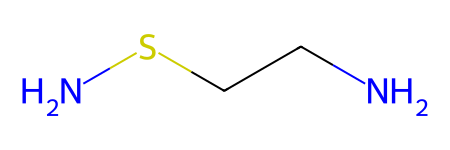

In [215]:
from rdkit.Chem import MolFromSmiles

smiles_a = "NSCCN"
MolFromSmiles(smiles_a)

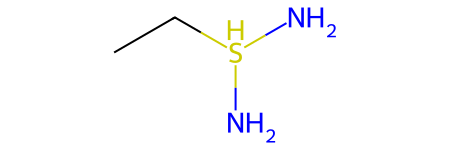

In [216]:
smiles_b = "NS(CC)N"
MolFromSmiles(smiles_b)

In [217]:
graph_a = smiles_to_graph_simple(smiles_a)
graph_b = smiles_to_graph_simple(smiles_b)
batch = dgl.batch([graph_a, graph_b])

### Task 5. Expressiveness of a Transformer as a GNN (2 points).
Using the code provided below, run few experiments and answer the following questions:
1. Explain why the Transformer-based GNN can (or cannot) distinguish between the two molecules.
***The particles can be different, but features of the nodes can be similar. Thus examining local properties might not capture the full information.***
2. Why can (or cannot) we make the Transformer-based GNN to distinguish between the molecules by manipulating the number of layers?
***Since then we will also focus on more node features, it might not improve our approach.***
3. Explain why the GAT-based GNN can (or cannot) distinguish between the two molecules.
***Even adding the information about the connectivity of the nodes, as in the example, does not capture the information about the global structure.***
4. Why can (or cannot) we make the GAT-based GNN to distinguish between the molecules by manipulating the number of layers?
***Since then we will also focus on more node features and local connectivity of the nodes, it might still not see global features.***

In [344]:
transformer = transformer_gnn(node_features_size=atom_type_featurizer.feat_size(), n_layers=30)
transformer(batch)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (20x59 and 43x64)

In [219]:
gat = gat_gnn(node_features_size=atom_type_featurizer.feat_size(), n_layers=30)
gat(batch)

tensor([[0.133845],
        [0.133845]], grad_fn=<AddmmBackward0>)

# Positional Encodings
As you finished the previous task, you know that our Transformer-based GNN cannot distinguish between the two molecules, and you know the exact reason. To overcome that reason, we can use structural encodings which are the analog of positional encodings used in the original textual Transformer. The purpose of the structural encoding is to encode the structure of a graph into the initial node features. For example, we can use the random walk positional encoding from dgllife package: [RandomWalkPE](https://docs.dgl.ai/en/1.1.x/generated/dgl.transforms.RandomWalkPE.html):


In [240]:
from dgllife.utils.mol_to_graph import construct_bigraph_from_mol
from dgl import random_walk_pe
from rdkit import Chem


class PositionalEncodingFeaturizerBase:
    @abstractmethod
    def feat_size(self) -> int:
        pass


class JointFeaturizer:
    def __init__(self, atom_featurizer: BaseAtomFeaturizer, pe_featurizer: PositionalEncodingFeaturizerBase):
        self.atom_featurizer = atom_featurizer
        self.pe_featurizer = pe_featurizer

    def feat_size(self) -> int:
        return self.atom_featurizer.feat_size() + self.pe_featurizer.feat_size()

    def __call__(self, mol: Chem.Mol):
        atom_features = self.atom_featurizer(mol)['h']
        pe_features = self.pe_featurizer(mol)
        return {'h': torch.cat([atom_features, pe_features], dim=-1)}


class RandomWalkPEFeaturizer(PositionalEncodingFeaturizerBase):
    def __init__(self, n_steps: int = 16):
        self.n_steps = n_steps

    def feat_size(self) -> int:
        return self.n_steps

    def __call__(self, mol: Chem.Mol):
        graph = construct_bigraph_from_mol(mol)
        return random_walk_pe(
            graph, k=self.n_steps
        )


## Task 6. Random walk. (1 points).
Given the following code:
```
smiles = 'C1CCC2CCCCC2C1'
mol = MolFromSmiles(smiles)
output = RandomWalkPEFeaturizer(n_steps=16)(mol)
```
Briefly explain the meaning of the `output[i, k]` value. Is it a probability of some event? What is the event?

***This is the probability that in n_step we will go from node i to node k. We also assume for each node choices of all edges have the same probability.***

In [241]:
node_pe_featurizer = JointFeaturizer(
    atom_featurizer=atom_type_featurizer,
    pe_featurizer=RandomWalkPEFeaturizer(n_steps=16),
)
smiles_to_graph_pe = SMILESToBigraph(
    node_featurizer=node_pe_featurizer,
    add_self_loop=True,
)

We can now observe the effect of the positional encodings on the Transformer-based GNN:

In [239]:
graph_a = smiles_to_graph_pe(smiles_a)
graph_b = smiles_to_graph_pe(smiles_b)
batch = dgl.batch([graph_a, graph_b])
transformer = transformer_gnn(node_features_size=node_pe_featurizer.feat_size(), n_layers=3)
transformer(batch)

NameError: name 'MultiHeadAttention' is not defined

## Random Walk and expressiveness of MPNNs
Using random walk as a positional encoding can also help MPNN to be more expressive (distinguish more non-isomorphic graphs).

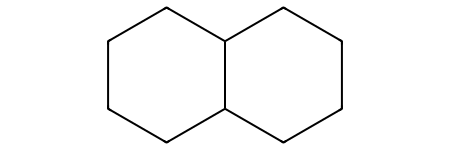

In [242]:
smiles_a = 'C1CCC2CCCCC2C1'
MolFromSmiles(smiles_a)

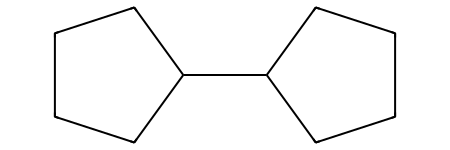

In [243]:
smiles_b = 'C1CCC(C1)C2CCCC2'
MolFromSmiles(smiles_b)

### Task 7. Expressiveness of a MPNN (2 points).
Using the code provided below, run few experiments and answer the following questions:
1. Explain why the GAT-based GNN can (or cannot) distinguish between the two molecules.
***They might have troubles, since measuring the node features and local conntctivity might not be sufficient, as on the example.***
2. Explain why the Transformer-based GNN with random walk positional encodings can (or cannot) distinguish between the two molecules.
***If the molecules differ in the way atoms are connected, with these positional encodings we will be able to distinguish these molecules.***
3. Explain why the GAT-based GNN with random walk positional encodings can (or cannot) distinguish between the two molecules.
***Now they differ a little, since we have taken into account some aproximation of the global structure. Thus it might help.***

In [244]:
graph_a = smiles_to_graph_simple(smiles_a)
graph_b = smiles_to_graph_simple(smiles_b)
batch = dgl.batch([graph_a, graph_b])
gat = gat_gnn(node_features_size=atom_type_featurizer.feat_size(), n_layers=3)
gat(batch)

tensor([[0.196707],
        [0.196707]], grad_fn=<AddmmBackward0>)

In [223]:
graph_a = smiles_to_graph_pe(smiles_a)
graph_b = smiles_to_graph_pe(smiles_b)
batch = dgl.batch([graph_a, graph_b])
transformer = transformer_gnn(node_features_size=node_pe_featurizer.feat_size(), n_layers=3)
transformer(batch)

NameError: name 'MultiHeadAttention' is not defined

In [245]:
graph_a = smiles_to_graph_pe(smiles_a)
graph_b = smiles_to_graph_pe(smiles_b)
batch = dgl.batch([graph_a, graph_b])
gat = gat_gnn(node_features_size=node_pe_featurizer.feat_size(), n_layers=3)
gat(batch)

tensor([[0.033193],
        [0.033141]], grad_fn=<AddmmBackward0>)

# Experiments
Ok, now we can quickly play with the Transformer-based and GAT-based GNNs and see how it performs on the molecular property prediction task.

In [226]:
from datetime import datetime
from torchmetrics import MeanAbsoluteError as MAE
from torchmetrics import MeanSquaredError as MSE
from torchmetrics import PearsonCorrCoef as PCC

metrics = {
    "mae": MAE(),
    "mse": MSE(),
    "pcc": PCC(),
}


def get_time_stamp() -> str:
    return datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

## Task 8. Train GAT (2 points).
1. Tune hyperparameters of a GNN with `GAT` as a layer to obtain at most 2.0 MAE on the validation set. You can modify the GNN/MPNN architecture so it uses regularization tricks. You can also change the featurization functions. Don't change the validation batch size. If your validation MAE is in (2.0, 2.5], you can obtain 1 point.
2. Report the obtained MAE on the validation and test set (only the former need to be lower than 2.0 MAE).
3. Provide the link to the final run: [your link]

In [227]:
node_featurizer = CanonicalAtomFeaturizer()
dataset = FreeSolv(
    smiles_to_graph=SMILESToBigraph(
        node_featurizer=node_featurizer,
        add_self_loop=True,
    )
)
splitter = ScaffoldSplitter()
train, valid, test = splitter.train_val_test_split(dataset)  # it's deterministic

model = GNN(
    node_features_size=node_featurizer.feat_size(),
    hidden_size=64,
    output_size=1,
    gnn_layer_cls=GATLayer,
    gnn_layer_kwargs={},
    gnn_n_layers=4,
    gnn_layer_requires_dense=False,
    readout_cls=SumReadout,
)

trainer = Trainer(
    run_dir="experiments",
    train_dataset=train,
    valid_dataset=valid,
    train_metrics=metrics,
    valid_metrics=metrics,
    train_batch_size=32,
    model=model,
    logger=WandbLogger(
        logdir="runs/mpnn",
        project_name="mldd23",
        experiment_name=f"gat_{get_time_stamp()}",
    ),
    optimizer_kwargs={"lr": 1e-4},
    n_epochs=100,
    device="cpu",
    valid_every_n_epochs=1,
)

valid_metrics = trainer.train()
test_metrics = trainer.test(test)
trainer.close()
print(f"Validation metrics: {valid_metrics}")
print(f"Test metrics: {test_metrics}")

Extracting file to /root/.dgl/FreeSolv
Processing dgl graphs from scratch...
Start initializing RDKit molecule instances...
Start computing Bemis-Murcko scaffolds.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit:

 ··········


wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


  0%|          | 0/100 [00:00<?, ?it/s]

test/loss,▁
test/mae,▁
test/mse,▁
test/pcc,▁
train/loss,▆▆▄▃█▄▅▄▃▅▇▃▃▃▃▂▃▂▂▂▂▂▂▂▂▁▁▁▂▂▁▁▁▁▁▂▂▁▂▂
train/mae,█▅▅▆▅▅▅▅▆▅▅▄▄▅▅▄▃▄▃▅▂▂▂▃▃▁▂▃▃▂▃▂▂▂▂▂▂▂▂▂
train/mse,▇█▃▄▃▄▃▄▃▇▃▄▃▃▃▂▂▃▃▃▂▂▁▂▂▁▂▂▂▂▂▂▁▂▁▁▂▂▂▂
train/pcc,▁▂▂▂▄▃▃▅▃▄▄▅▅ ▅▇ ▆▇▇█▆▇▇▇▇▆▇▇▇▇▇ ▇████▇▇
valid/loss,██▇▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▄▄▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁
valid/mae,██▅▅▅▅▅▅▅▅▅▅▅▅▄▄▄▄▃▃▃▂▂▂▂▂▂▂▂▂▁▂▂▂▁▁▁▁▁▁
valid/mse,██▄▄▄▄▄▄▄▄▄▄▄▄▃▂▂▂▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁


Validation metrics: {'loss': 9.781769752502441, 'mae': 1.9674677848815918, 'mse': 9.781769752502441, 'pcc': 0.8944093585014343}
Test metrics: {'loss': 7.239431667327881, 'mae': 2.2985055446624756, 'mse': 8.731088638305664, 'pcc': 0.7413514256477356}


## Task 9. Train Transformer (2 points).
1. Tune hyperparameters of a GNN with `Transformer` as a layer to obtain at most 2.0 MAE on the validation set. You can modify the GNN/MPNN architecture so it uses regularization tricks. You can also change the featurization functions. Don't change the validation batch size. If your validation MAE is in (2.0, 2.5], you can obtain 1 point.
2. Report the obtained MAE on the validation and test set (only the former need to be lower than 2.0 MAE).
3. Provide the link to the final run: [your link]

In [228]:
node_featurizer = CanonicalAtomFeaturizer()
dataset = FreeSolv(
    smiles_to_graph=SMILESToBigraph(
        node_featurizer=node_featurizer,
        add_self_loop=True,
    )
)
splitter = ScaffoldSplitter()
train, valid, test = splitter.train_val_test_split(dataset)  # it's deterministic

model = GNN(
    node_features_size=node_featurizer.feat_size(),
    hidden_size=64,
    output_size=1,
    gnn_layer_cls=TransformerLayer,
    gnn_layer_kwargs={},
    gnn_n_layers=4,
    gnn_layer_requires_dense=True,
    readout_cls=SumReadout,
)

trainer = Trainer(
    run_dir="experiments",
    train_dataset=train,
    valid_dataset=valid,
    train_metrics=metrics,
    valid_metrics=metrics,
    train_batch_size=32,
    model=model,
    logger=WandbLogger(
        logdir="runs/mpnn",
        project_name="mldd23",
        experiment_name=f"transformer_{get_time_stamp()}",
    ),
    optimizer_kwargs={"lr": 1e-4},
    n_epochs=100,
    device="cpu",
    valid_every_n_epochs=1,
)

valid_metrics = trainer.train()
test_metrics = trainer.test(test)
trainer.close()
print(f"Validation metrics: {valid_metrics}")
print(f"Test metrics: {test_metrics}")

Extracting file to /root/.dgl/FreeSolv
Processing dgl graphs from scratch...
Start initializing RDKit molecule instances...
Start computing Bemis-Murcko scaffolds.


NameError: name 'MultiHeadAttention' is not defined